# 01T — Coefficient reconstruction  ·  line T (testing)

Inverts HMI's cubic calibration (`hmi.coefficients`) to rebuild a dopplergram and
magnetogram from DS01's raw cubes, so that a *different* correction could be applied
instead.

**Parked, not retired.** Nothing in line A or line B calls this. It lives on the T line
because the option is wanted in the pipeline eventually, not because it is finished.

**The open caveat:** the reconstructed dopplergram does not reproduce the shipped
`cube_dopplergram_corrected.fits` — the correlation between them is about zero. The likeliest
reading is that the shipped file corrects something else (an orbital or gravitational-redshift
term) rather than the tuning nonlinearity this cubic describes. Until that is settled, treat
a reconstructed cube as an experiment, not as data. `03T_analysis_sandbox.ipynb` §4 sets up
the check that would answer it.

The maths now lives in `src/post_processing.py` (renamed from `hmi_coefficients.py`), with
`reconstruct_cubes()` generalising the loop this notebook used to spell out inline.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pathlib

# Ensure the notebook can import the local src package from the project root.
project_root = pathlib.Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root.resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sunpy.net import Fido, attrs as a
import astropy.units as u
from astropy.io import fits
import sunpy.map


from src.utilities import make_cube

# dowload Metada from Sebastian Sun spots

In [2]:
print(a.jsoc.Series)

sunpy.net.jsoc.attrs.Series

The JSOC Series to Download.

           Attribute Name           ...
----------------------------------- ...
aia_flatfield                       ...
aia_lev1                            ...
aia_lev1_euv_12s                    ...
aia_lev1_uv_24s                     ...
aia_lev1_vis_1h                     ...
aia_master_pointing3h               ...
aia_response                        ...
aia_temperature_summary_300s        ...
hmi_b_135s                          ...
hmi_b_5760s                         ...
hmi_b_720s                          ...
hmi_b_720s_dcon                     ...
hmi_b_720s_dcons                    ...
hmi_b_720s_e15w1332_cea             ...
hmi_b_720s_e15w1332_cutout          ...
hmi_b_90s                           ...
hmi_b_synoptic                      ...
hmi_b_synoptic_small                ...
hmi_bharp_720s                      ...
hmi_bharp_720s_nrt                  ...
hmi_bmap_lowres_latlon_720s         ...
hmi_bptr_720s_mod    

hmi_lookup_chebycoef_bnoise  
hmi_lookup_corrected_expanded
hmi_lookup_expanded          
hmi_coefficients             

## Recover sky coordinates of a sunspot mask (DS01) for a JSOC cutout

`DS01` (like every `sebastian_sun_spots/DSxx` folder) does **not** store a saved
pixel mask. Instead the sunspot footprint is computed on the fly by
`src.loaders.load_ds0n_region()`, which thresholds `cube_continuum.fits`
into `umbra` / `penumbra` / `both` boolean cubes of shape `(n_t, 239, 239)`.

Two companion cubes give the physical location of every one of those pixels:

- `cube_xcoord.fits`, `cube_ycoord.fits` — `(1067, 239, 239)` float32 cubes.
  For each time frame `t` and pixel `(j, i)` they hold the pixel's
  **Helioprojective-Cartesian (Tx, Ty) coordinates, in arcsec** — i.e. the
  same `(Tx, Ty)` "solar-x / solar-y" system used for `bottom_left` /
  `top_right` in `01_download_data.ipynb`. This is confirmed by the WCS
  keywords on the reference headers shipped alongside the cubes
  (`CTYPE1/2 = HPLN-TAN / HPLT-TAN`, `CUNIT1/2 = arcsec`), and by
  `cube_mu.fits` (cosine of the heliocentric viewing angle), which is the
  standard companion of an HPC pixel grid.
- `cube_continuum_coords2times.sav` — an IDL save file with:
  - `hdrs`: the **full per-frame FITS header** (1067 of them), including the
    observer geometry (`DSUN_OBS`, `CRLN_OBS`, `CRLT_OBS`, `RSUN_REF`) and
    `T_OBS` needed to build the exact `Helioprojective` frame for any frame.
  - `times`: the per-frame observation timestamp.
  - `xd`, `yd`: the tracked region center's drift in arcsec over time.

So mask pixels index directly into `cube_xcoord` / `cube_ycoord` — no WCS
`pixel_to_world` step is required, since those cubes already *are* the world
coordinates. We only need `Helioprojective`/`HeliographicStonyhurst` (via the
first frame's header) to attach the correct observer + obstime to the raw
`(Tx, Ty)` numbers, producing `SkyCoord` objects usable exactly like
`bottom_left` / `top_right` in `01_download_data.ipynb` for `a.jsoc.Cutout`.

In [3]:
from scipy.io import readsav

from src.loaders import load_ds0n_region

ds01_dir = project_root / 'data' / 'raw' / 'sebastian_sun_spots' / 'DS01'

# Sunspot mask cubes (n_t, 239, 239) — computed from cube_continuum.fits thresholding.
# filter_both=True keeps 'both' consistent with the central-cluster-filtered umbra/penumbra.
mask_data = load_ds0n_region(ds01_dir, filter_both=True)
mask_union = mask_data['both'].any(axis=0)   # (239, 239) — footprint over the whole time series
print(f"n_t = {mask_data['n_t']}, mask shape = {mask_union.shape}, "
      f"pixels in union mask = {mask_union.sum()}")

# Per-pixel, per-frame Helioprojective (Tx, Ty) coordinates in arcsec — same grid as the masks.
with fits.open(ds01_dir / 'cube_xcoord.fits') as hdul:
    cube_xcoord = hdul[0].data.astype(float)
with fits.open(ds01_dir / 'cube_ycoord.fits') as hdul:
    cube_ycoord = hdul[0].data.astype(float)
print(f"cube_xcoord shape = {cube_xcoord.shape}")

# Per-frame FITS headers + timestamps (gives the observer geometry needed to build a SkyCoord).
coords2times = readsav(ds01_dir / 'cube_continuum_coords2times.sav')
hdrs = coords2times['hdrs']
print(f"n_hdrs = {len(hdrs)}, first T_OBS = {hdrs[0]['T_OBS']}")

n_t = 1067, mask shape = (239, 239), pixels in union mask = 7509
cube_xcoord shape = (1067, 239, 239)
n_hdrs = 1067, first T_OBS = b'2017.08.12_04:48:52_TAI'


In [4]:
# The cutout cubes are already rotation-tracked, so a given pixel index (j, i)
# follows the same tracked patch of sky across frames. We therefore evaluate the
# union mask's pixel indices against a single reference frame (t=0) to get the
# (Tx, Ty) box to hand to a.jsoc.Cutout(..., tracking=True), which will itself
# track that box forward in time from the first requested timestamp.
ref_frame = 0

tx_masked = cube_xcoord[ref_frame][mask_union]
ty_masked = cube_ycoord[ref_frame][mask_union]

tx_min, tx_max = tx_masked.min(), tx_masked.max()
ty_min, ty_max = ty_masked.min(), ty_masked.max()

# ~10% padding on each axis
pad_x = 0.10 * (tx_max - tx_min)
pad_y = 0.10 * (ty_max - ty_min)
tx_min, tx_max = tx_min - pad_x, tx_max + pad_x
ty_min, ty_max = ty_min - pad_y, ty_max + pad_y

print(f"Tx range (padded): [{tx_min:.2f}, {tx_max:.2f}] arcsec")
print(f"Ty range (padded): [{ty_min:.2f}, {ty_max:.2f}] arcsec")

Tx range (padded): [-825.15, -791.77] arcsec
Ty range (padded): [-184.31, -126.28] arcsec


In [5]:
from astropy.coordinates import SkyCoord
from astropy.time import Time
from sunpy.coordinates import HeliographicStonyhurst, Helioprojective

# `hdrs` is stored in *reverse* chronological order relative to cube_xcoord /
# cube_ycoord / times (verified: hdrs[0]['T_OBS'] is the Aug-12 frame, while
# cube_xcoord[0] sits at the Aug-3 near-east-limb position from SRS_info_AR.csv).
ref_hdr = hdrs[mask_data['n_t'] - 1 - ref_frame]


def parse_tai(t_obs) -> Time:
    """'2017.08.03_03:00:15_TAI' -> astropy Time (scale='tai')."""
    s = t_obs.decode() if isinstance(t_obs, bytes) else t_obs
    date_part, time_part, _ = s.split('_')
    return Time(f"{date_part.replace('.', '-')}T{time_part}", scale='tai')


obstime = parse_tai(ref_hdr['T_OBS'])
observer = HeliographicStonyhurst(
    lon=float(ref_hdr['CRLN_OBS']) * u.deg,
    lat=float(ref_hdr['CRLT_OBS']) * u.deg,
    radius=float(ref_hdr['DSUN_OBS']) * u.m,
    obstime=obstime,
)
hpc_frame = Helioprojective(observer=observer, obstime=obstime, rsun=float(ref_hdr['RSUN_REF']) * u.m)

bottom_left_ds01 = SkyCoord(tx_min * u.arcsec, ty_min * u.arcsec, frame=hpc_frame)
top_right_ds01   = SkyCoord(tx_max * u.arcsec, ty_max * u.arcsec, frame=hpc_frame)

print(f"obstime           : {obstime.iso} TAI")
print(f"bottom_left (Tx,Ty): ({bottom_left_ds01.Tx:.2f}, {bottom_left_ds01.Ty:.2f})")
print(f"top_right   (Tx,Ty): ({top_right_ds01.Tx:.2f}, {top_right_ds01.Ty:.2f})")

obstime           : 2017-08-03 03:00:52.000 TAI
bottom_left (Tx,Ty): (-825.15 arcsec, -184.31 arcsec)
top_right   (Tx,Ty): (-791.77 arcsec, -126.28 arcsec)


In [6]:
# Sanity check — same pattern as 01_download_data.ipynb: hand the SkyCoords to
# a.jsoc.Cutout and confirm JSOC can find frames for this region/time range.
cutout_ds01 = a.jsoc.Cutout(bottom_left_ds01, top_right=top_right_ds01, tracking=True)

result_ds01 = Fido.search(
    a.Time(obstime, obstime + 10 * u.min),
    a.jsoc.Series('hmi.Ic_45s'),
    a.jsoc.Notify('thomas.quamtum@gmail.com'),
    cutout_ds01,
)
print(result_ds01)

Results from 1 Provider:

14 Results from the JSOCClient:
Source: http://jsoc.stanford.edu

         T_REC          TELESCOP  INSTRUME  WAVELNTH CAR_ROT
----------------------- -------- ---------- -------- -------
2017.08.03_03:00:45_TAI  SDO/HMI HMI_FRONT2   6173.0    2193
2017.08.03_03:01:30_TAI  SDO/HMI HMI_FRONT2   6173.0    2193
2017.08.03_03:02:15_TAI  SDO/HMI HMI_FRONT2   6173.0    2193
2017.08.03_03:03:00_TAI  SDO/HMI HMI_FRONT2   6173.0    2193
2017.08.03_03:03:45_TAI  SDO/HMI HMI_FRONT2   6173.0    2193
2017.08.03_03:04:30_TAI  SDO/HMI HMI_FRONT2   6173.0    2193
2017.08.03_03:05:15_TAI  SDO/HMI HMI_FRONT2   6173.0    2193
2017.08.03_03:06:00_TAI  SDO/HMI HMI_FRONT2   6173.0    2193
2017.08.03_03:06:45_TAI  SDO/HMI HMI_FRONT2   6173.0    2193
2017.08.03_03:07:30_TAI  SDO/HMI HMI_FRONT2   6173.0    2193
2017.08.03_03:08:15_TAI  SDO/HMI HMI_FRONT2   6173.0    2193
2017.08.03_03:09:00_TAI  SDO/HMI HMI_FRONT2   6173.0    2193
2017.08.03_03:09:45_TAI  SDO/HMI HMI_FRONT2   6173.0  

In [7]:
download_dir = pathlib.Path('../data/raw/sebastian_sun_spots/DS01_metadata')
download_dir.mkdir(parents=True, exist_ok=True)

#files_ds01 = Fido.fetch(result_ds01, path=download_dir)

print(f"Download directory: {download_dir.resolve()}")



Download directory: /mnt/shared/Projects/sun_spots_pulsation_review/data/raw/sebastian_sun_spots/DS01_metadata


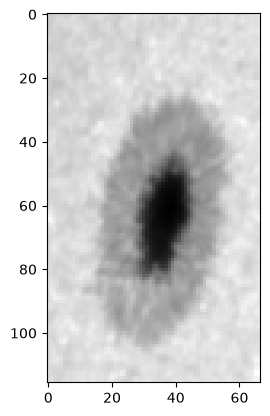

In [8]:
file_list = sorted(download_dir.glob('hmi.ic_45s*.continuum.fits'))


with fits.open(file_list[0]) as hdu:
    data_shape = hdu[1].data.shape
    header = hdu[1].header.copy()

plt.imshow(hdu[1].data, cmap='gray')
plt.show()

# dowload the metada corresponding to the cutout

## lookup table

In [9]:
# The strings printed under `a.jsoc.Series` (e.g. `hmi_lookup_chebycoef_bnoise`) are the
# *Python attribute names* sunpy exposes for tab-completion — not real JSOC series names.
# The actual series name (what JSOC's DRMS expects) is the `.value` of that attribute, and
# uses dots, e.g. `s.hmi_lookup_chebycoef_bnoise.value == 'hmi.lookup_chebycoef_bnoise'`
# (same pattern as `hmi.Ic_45s` used above). Passing the underscored attribute name to
# a.jsoc.Series() is what produced "Invalid series name. [status=4]".
#
# Also: none of these four series are spatial image products, so `a.jsoc.Cutout` does not
# apply to them (confirmed via `drms.Client().info(series).primekeys`):
#   - hmi.lookup_chebycoef_bnoise    -> keyed by (VRCENT, MASKID), not T_REC
#   - hmi.lookup_expanded            -> keyed by (FSN_REC, T_REC, HCAMID, HWL1-4POS, NWL)
#   - hmi.lookup_corrected_expanded  -> keyed by (FSN_REC, T_REC, HCAMID, HWL1-4POS, NWL)
#   - hmi.coefficients               -> keyed by T_REC only
# They are full-disk calibration/lookup tables (noise masks, MDI-like lookup tables,
# polynomial fit coefficients), not per-pixel HPC maps — there is no sunspot-region cutout
# to request. Query them with a.Time alone.

series_names = [
    a.jsoc.Series.hmi_lookup_chebycoef_bnoise.value,
#    a.jsoc.Series.hmi_lookup_corrected_expanded.value,
#    a.jsoc.Series.hmi_lookup_expanded.value,
#    a.jsoc.Series.hmi_coefficients.value,
]

for series in series_names:
    result = Fido.search(
        a.Time(obstime, obstime + 10 * u.min),
        a.jsoc.Series(series),
        a.jsoc.Notify('thomas.quamtum@gmail.com'),
    )
    n = len(result[0]) if len(result) else 0
    print(f"{series}: {n} results")

hmi.lookup_chebycoef_bnoise: 1791 results


In [10]:
a.jsoc.Series.hmi_lookup_expanded.value

'hmi.lookup_expanded'

In [11]:
#1files_loopup_ds01 = Fido.fetch(result, path=download_dir)

## coeficients

In [12]:
import drms
client = drms.Client()

# Ver estructura de la serie
si = client.info('hmi.coefficients')
print(si.primekeys)   # te dice cuáles son las claves primarias reales
print(si.keywords.index.tolist())

['T_REC']
['T_REC', 'T_START', 'T_STOP', 'DATAUSED', 'CAL_FSN', 'DATE', 'NDATA', 'COEFF0', 'COEFF1', 'COEFF2', 'COEFF3']


In [13]:
str(obstime)

'2017-08-03T03:00:52.000'

In [14]:
query = client.query('hmi.coefficients[2017.08.03_TAI/1d]',key=si.keywords.index.tolist())
query

,T_REC,T_START,T_STOP,DATAUSED,CAL_FSN,DATE,NDATA,COEFF0,COEFF1,COEFF2,COEFF3
0,2017.08.03_06:45:00_TAI,2017.08.02_18:45:00_TAI,2017.08.03_18:45:00_TAI,hmi.V_45s_nrt[2017.08.02_18:45:00_TAI-2017.08....,121048472,2017-08-06T16:45:34Z,1881,188.0067,0.006999,-0.000007,-8.414051e-10
1,2017.08.03_18:45:00_TAI,2017.08.03_06:45:00_TAI,2017.08.04_06:45:00_TAI,hmi.V_45s_nrt[2017.08.03_06:45:00_TAI-2017.08....,121048472,2017-08-07T16:50:48Z,1887,187.5741,0.006670,-0.000007,-8.199870e-10


## removing coeficients effects from data 

In [15]:
data = query.iloc[0]

In [16]:
# Source - https://stackoverflow.com/a/72810956
# Posted by J. Choi, modified by community. See post 'Timeline' for change history
# Retrieved 2026-08-04, License - CC BY-SA 4.0

import sympy

x = sympy.symbols('x')
y = sympy.symbols('y')
c0 = data['COEFF0']
c1 = data['COEFF1']
c2 = data['COEFF2']
c3 = data['COEFF3']

expr = (c0 + c1*x + c2*x**2 + c3*x**3)

eqn = sympy.Eq(y, expr)
inv = sympy.solve(eqn, x)


given that the dopler velocity and the magnetic field are computed as 

$$
V = \frac{V_{lcp}+V_{rcp}}{2}
$$

and 

$$
B = (V_{lcp}-V_{rcp})K; K = 1.0 / (2.0\times 4.67 \cdot 10^{-5} \times 0.000061733433\times 2.5\times 299792458.0)
$$

## Reconstructing a corrected dopplergram + magnetogram from the raw cubes

DS01 ships a *corrected* dopplergram but no corrected magnetogram at all — only the raw
`cube_magnetogram.fits`. Both are derived from the per-camera velocities `V_lcp`/`V_rcp`
(formula above), and JSOC's correction is a per-time cubic polynomial (`hmi.coefficients`,
COEFF0..3) applied to those velocities.

Pipeline:
1. Load the **raw** dopplergram + magnetogram cubes.
2. Derive raw `V_lcp`, `V_rcp` from them via the `V`, `B` formula above.
3. Fetch `hmi.coefficients` for the full DS01 time span and match each of the 1067 frames to
   the coefficient row whose `[T_START, T_STOP)` window contains its `T_OBS` (coefficients
   change roughly every 12 h, so this must be per-frame, not a single hardcoded row).
4. Invert the per-frame cubic on `V_lcp`, `V_rcp` to get the "uncorrected" velocities.
5. Re-derive `V`, `B` from the uncorrected velocities → the reconstructed corrected
   dopplergram + magnetogram.
6. Save the reconstructed cubes to disk, mask them with the existing region-mask pipeline, and
   plot mean B/Doppler per region — once with the parabolic-fit magnetogram residual enabled,
   once with the quiet-sun signal subtracted.

All of the coefficient-fetching / inversion / V↔V_lcp,V_rcp code lives in
`src/hmi_coefficients.py`; the vectorized vs. the single-row `sympy` inversion above are
equivalent — the vectorized version is what's actually used here since `sympy.solve` is far too
slow to run per-pixel over a `(1067, 239, 239)` cube.

**Units note**: `hmi.coefficients` values (e.g. `COEFF0≈188`, `COEFF1≈0.007`) are far from an
identity transform, so this is *not* a small perturbation of `x` — inverting it can noticeably
amplify or shift the value (`dx/dy ≈ 1/COEFF1 ≈ 140`, so the correction has real leverage). `x`
is taken directly in m/s (the same units as the raw dopplergram cubes), which is the physically
sensible choice: for ~99.9% of pixels the cubic has a single real root (well-posed inversion);
for the small remainder with three real roots, the root closest to `y` itself is picked as a
generic, assumption-free tie-breaker (see `invert_cubic` in `src/hmi_coefficients.py`). The
reconstructed dopplergram does **not** closely match the shipped `cube_dopplergram_corrected.fits`
(correlation ≈ 0 in a quick check) — that file likely corrects for a different effect (e.g.
orbital/gravitational redshift) than this polynomial, which is JSOC's "MDI-like algorithm"
phase/tuning correction, so a mismatch there isn't necessarily a bug in this pipeline. Treat the
`_reconstructed` cubes as a distinct calibration product, not a reproduction of
`_corrected.fits`.

In [17]:
raw_data = load_ds0n_region(ds01_dir, raw_dopler=True)
print(
    f"n_t={raw_data['n_t']}  "
    f"cube_dop (raw) range=[{np.nanmin(raw_data['cube_dop']):.1f}, {np.nanmax(raw_data['cube_dop']):.1f}] m/s  "
    f"cube_mag (always raw) range=[{np.nanmin(raw_data['cube_mag']):.1f}, {np.nanmax(raw_data['cube_mag']):.1f}] G"
)

n_t=1067  cube_dop (raw) range=[-6593.7, 6217.3] m/s  cube_mag (always raw) range=[-1057.1, 2396.8] G


In [18]:
import datetime as _dt

# Read the dopplergram cube's own per-frame timestamps (rather than reusing the continuum
# ones) since the coefficient inversion is applied to the dopplergram/magnetogram-derived
# velocities specifically.
dop_times_sav = readsav(ds01_dir / 'cube_dopplergram_coords2times.sav')
_raw_times = dop_times_sav['times'].flatten().astype(str)
_dt_times = [_dt.datetime.strptime(t, '%d-%b-%Y %H:%M:%S.%f') for t in _raw_times]
obs_times = Time(_dt_times, scale='tai')

print(f"obs_times: n={len(obs_times)}, first={obs_times[0].iso}, last={obs_times[-1].iso}")

obs_times: n=1067, first=2017-08-03 03:00:15.000, last=2017-08-12 04:48:15.000


In [19]:
from src.post_processing import (
    K, fetch_coefficients, match_coefficients_to_times, apply_cubic, invert_cubic,
    vlcp_rcp_from_v_b, v_b_from_vlcp_rcp,
)

coeff_df = fetch_coefficients(obs_times.min(), obs_times.max())
c0, c1, c2, c3 = match_coefficients_to_times(obs_times, coeff_df)

n_unique = coeff_df.shape[0]
print(f"Fetched {n_unique} hmi.coefficients rows spanning the DS01 time range; "
      f"matched all {len(c0)} frames to a coefficient row.")

2026-08-04 22:54:45 - astropy - WARNING: TimeDeltaMissingUnitWarning: Numerical value without unit or explicit format passed to TimeDelta, assuming days


Fetched 22 hmi.coefficients rows spanning the DS01 time range; matched all 1067 frames to a coefficient row.


In [20]:
# Raw (uncorrected) dopplergram + magnetogram -> raw V_lcp / V_rcp
V_lcp_raw, V_rcp_raw = vlcp_rcp_from_v_b(raw_data['cube_dop'], raw_data['cube_mag'], K)

print(f"V_lcp_raw range: [{np.nanmin(V_lcp_raw):.1f}, {np.nanmax(V_lcp_raw):.1f}] m/s")
print(f"V_rcp_raw range: [{np.nanmin(V_rcp_raw):.1f}, {np.nanmax(V_rcp_raw):.1f}] m/s")

V_lcp_raw range: [-6350.0, 7288.3] m/s
V_rcp_raw range: [-7967.1, 6789.7] m/s


In [21]:
# Invert the per-frame cubic (velocities in m/s) to get the "uncorrected" velocities:
# these are V_lcp/V_rcp as they were *before* JSOC's polynomial correction.
V_lcp_unc = invert_cubic(V_lcp_raw, c0, c1, c2, c3)
V_rcp_unc = invert_cubic(V_rcp_raw, c0, c1, c2, c3)

print(f"V_lcp_unc range: [{np.nanmin(V_lcp_unc):.1f}, {np.nanmax(V_lcp_unc):.1f}] m/s")
print(f"V_rcp_unc range: [{np.nanmin(V_rcp_unc):.1f}, {np.nanmax(V_rcp_unc):.1f}] m/s")

V_lcp_unc range: [-23905.0, 17730.8] m/s
V_rcp_unc range: [-22971.5, 19226.7] m/s


In [22]:
# Re-derive V, B from the uncorrected velocities -> the reconstructed corrected
# dopplergram + magnetogram.
cube_dop_recon, cube_mag_recon = v_b_from_vlcp_rcp(V_lcp_unc, V_rcp_unc, K)

print(f"Reconstructed dopplergram range: [{np.nanmin(cube_dop_recon):.1f}, {np.nanmax(cube_dop_recon):.1f}] m/s")
print(f"Reconstructed magnetogram range: [{np.nanmin(cube_mag_recon):.1f}, {np.nanmax(cube_mag_recon):.1f}] G")

# Reference only — NOT expected to match closely (see units note above): the shipped
# "corrected" dopplergram likely corrects a different effect (e.g. orbital/gravitational
# redshift) than the hmi.coefficients polynomial reconstructed here.
with fits.open(ds01_dir / 'cube_dopplergram_corrected.fits') as hdul:
    cube_dop_shipped = hdul[0].data.astype(float)

_diff = cube_dop_recon - cube_dop_shipped
_finite = np.isfinite(_diff)
_corr = np.corrcoef(cube_dop_recon[_finite], cube_dop_shipped[_finite])[0, 1]
print(
    f"Reconstructed vs shipped corrected dopplergram: "
    f"mean diff={np.nanmean(_diff[_finite]):.2f} m/s, std={np.nanstd(_diff[_finite]):.2f} m/s, "
    f"correlation={_corr:.3f}"
)

Reconstructed dopplergram range: [-22464.5, 17975.5] m/s
Reconstructed magnetogram range: [-8828.8, 6549.7] G
Reconstructed vs shipped corrected dopplergram: mean diff=-1190.45 m/s, std=13769.34 m/s, correlation=-0.104


In [23]:
# Apply the exact same reconstruction (raw -> V_lcp/V_rcp -> invert per-frame cubic -> V, B)
# to the quiet-sun patch cubes, using the same per-frame c0..c3 (same time axis, n_t=1067).
V_lcp_qsun_raw, V_rcp_qsun_raw = vlcp_rcp_from_v_b(
    raw_data['cube_dop_qsun'], raw_data['cube_mag_qsun'], K
)
V_lcp_qsun_unc = invert_cubic(V_lcp_qsun_raw, c0, c1, c2, c3)
V_rcp_qsun_unc = invert_cubic(V_rcp_qsun_raw, c0, c1, c2, c3)
cube_dop_qsun_recon, cube_mag_qsun_recon = v_b_from_vlcp_rcp(V_lcp_qsun_unc, V_rcp_qsun_unc, K)

print(f"Quiet-sun raw dopplergram range: [{np.nanmin(raw_data['cube_dop_qsun']):.1f}, {np.nanmax(raw_data['cube_dop_qsun']):.1f}] m/s")
print(f"Quiet-sun reconstructed dopplergram range: [{np.nanmin(cube_dop_qsun_recon):.1f}, {np.nanmax(cube_dop_qsun_recon):.1f}] m/s")
print(f"Quiet-sun raw magnetogram range: [{np.nanmin(raw_data['cube_mag_qsun']):.1f}, {np.nanmax(raw_data['cube_mag_qsun']):.1f}] G")
print(f"Quiet-sun reconstructed magnetogram range: [{np.nanmin(cube_mag_qsun_recon):.1f}, {np.nanmax(cube_mag_qsun_recon):.1f}] G")

Quiet-sun raw dopplergram range: [-4633.6, 4095.0] m/s
Quiet-sun reconstructed dopplergram range: [-20299.8, 16015.6] m/s
Quiet-sun raw magnetogram range: [-665.0, 640.2] G
Quiet-sun reconstructed magnetogram range: [-4863.5, 5415.1] G


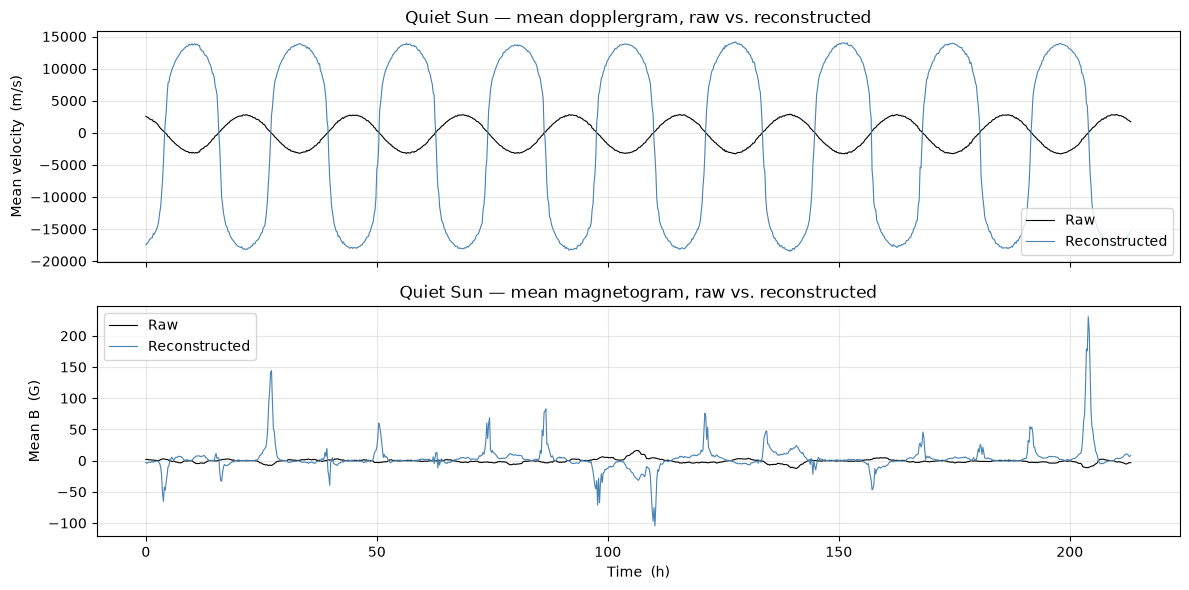

In [24]:
# Quiet-sun behaviour, raw vs. reconstructed — dopplergram and magnetogram.
qsun_dop_raw_mean   = np.nanmean(raw_data['cube_dop_qsun'], axis=(1, 2))
qsun_dop_recon_mean = np.nanmean(cube_dop_qsun_recon, axis=(1, 2))
qsun_mag_raw_mean   = np.nanmean(raw_data['cube_mag_qsun'], axis=(1, 2))
qsun_mag_recon_mean = np.nanmean(cube_mag_qsun_recon, axis=(1, 2))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(raw_data['time_h'], qsun_dop_raw_mean,   color='black',      lw=0.8, label='Raw')
ax1.plot(raw_data['time_h'], qsun_dop_recon_mean, color='steelblue',  lw=0.8, label='Reconstructed')
ax1.set_ylabel('Mean velocity  (m/s)'); ax1.set_title('Quiet Sun — mean dopplergram, raw vs. reconstructed')
ax1.grid(alpha=0.3); ax1.legend()

ax2.plot(raw_data['time_h'], qsun_mag_raw_mean,   color='black',     lw=0.8, label='Raw')
ax2.plot(raw_data['time_h'], qsun_mag_recon_mean, color='steelblue', lw=0.8, label='Reconstructed')
ax2.set_ylabel('Mean B  (G)'); ax2.set_xlabel('Time  (h)')
ax2.set_title('Quiet Sun — mean magnetogram, raw vs. reconstructed')
ax2.grid(alpha=0.3); ax2.legend()

plt.tight_layout()
plt.show()

In [25]:
from src import post_processing




Skipping (already exists): /mnt/shared/Projects/sun_spots_pulsation_review/data/raw/sebastian_sun_spots/DS01/cube_dopplergram_reconstructed.fits
Skipping (already exists): /mnt/shared/Projects/sun_spots_pulsation_review/data/raw/sebastian_sun_spots/DS01/cube_magnetogram_reconstructed.fits


In [26]:
from src.analysis import add_mag_residuals, compute_metrics, plot_time_series
from src.segmentation import masks_from_cubes

data_recon = masks_from_cubes(
    raw_data['cube_cont'], cube_mag_recon, cube_dop_recon,
    cube_dop_qsun_recon, cube_mag_qsun_recon,
    cadence_s=raw_data['cadence_s'],
)
metrics_recon = compute_metrics(data_recon)

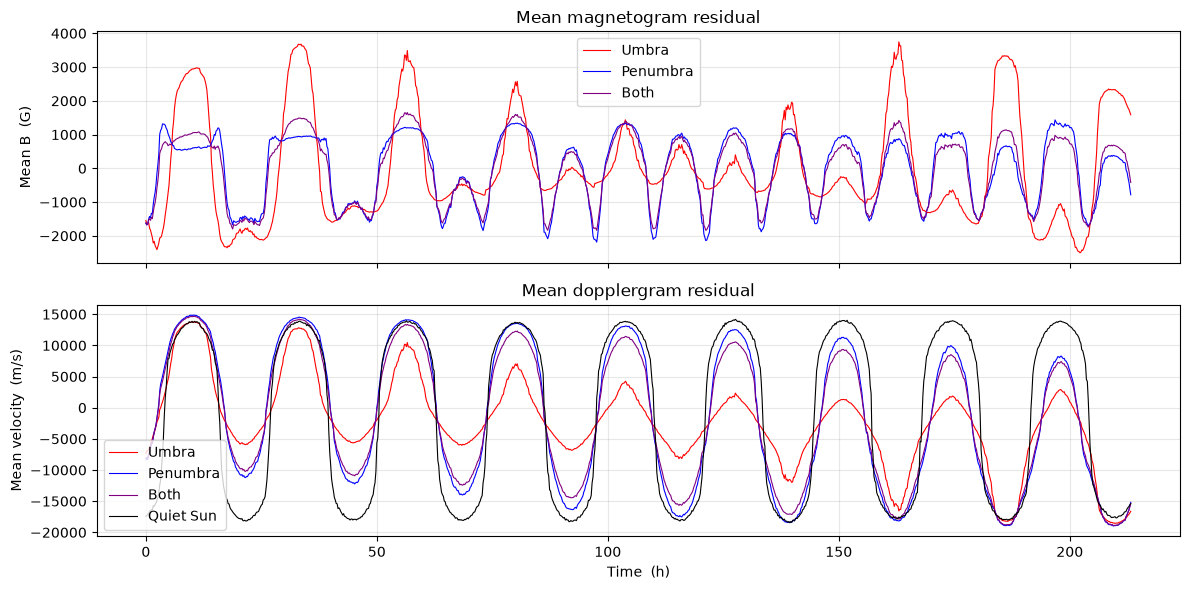

In [27]:
# Plot 1 — quadratic-fit magnetogram residual enabled (removes the slow systematic trend).
metrics_recon = add_mag_residuals(data_recon, metrics_recon)
plot_time_series(data_recon, metrics_recon, mag_residual=True)

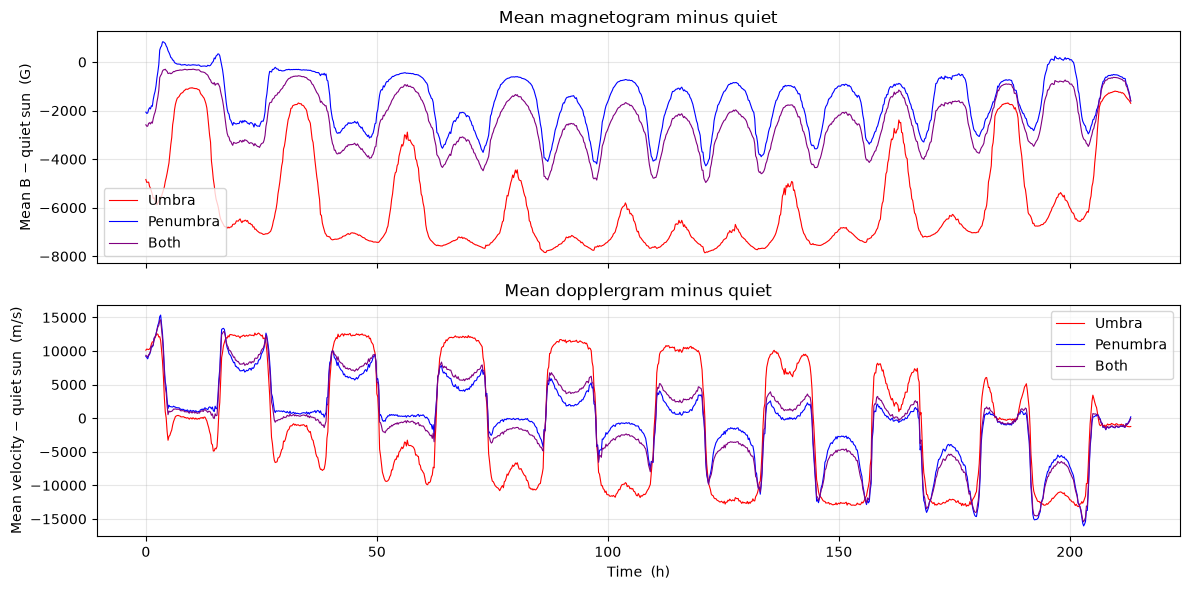

In [28]:
# Plot 2 — quiet-sun subtracted from each region's mean B / Doppler velocity.
plot_time_series(data_recon, metrics_recon, subtract_quiet=True)